# Post-Fire Landslide Susceptibility Modeling — Nacimiento, Chile
### Variables 3 & 4: Geology and Land Use / Land Cover

**Author:** Constanza Morales Gajardo
**Part of:** Landslide Susceptibility Portfolio Project (P5)

## 1. Introduction

This notebook derives the remaining two conditioning variables for the post-fire landslide susceptibility model: geology (lithology) and land use / land cover.

- **Study area:** Nacimiento commune (GADM boundary, `NAME_3`)
- **Data sources:** 
  - Land use/land cover: ESA WorldCover 10m (2021)
  - Geology: SERNAGEOMIN Portal Geomin REST service (primary), with GLiM (Global Lithological Map) as fallback if access proves unreliable
- **Tools:** Google Earth Engine Python API, geemap, geopandas, requests

In [1]:
import ee
import geemap
import geopandas as gpd
import requests
import os

# Initialize Earth Engine
ee.Initialize(project='earth-engine-portfolio-498609')

print("Earth Engine initialized successfully")

Earth Engine initialized successfully


## 2. Study Area — Nacimiento Commune Boundary

In [2]:
# Load Chile administrative boundaries (GADM level 3)
gadm_path = "../../nacimiento-wildfire-2023/data/raw/gadm41_CHL.gpkg"

if not os.path.exists(gadm_path):
    print(f"File not found at: {gadm_path}")
else:
    chile_admin = gpd.read_file(gadm_path, layer='ADM_ADM_3')
    nacimiento = chile_admin[chile_admin['NAME_3'] == 'Nacimiento']
    print(f"Nacimiento boundary loaded: {len(nacimiento)} feature(s)")

# Convert to Earth Engine geometry
aoi = geemap.geopandas_to_ee(nacimiento)

Nacimiento boundary loaded: 1 feature(s)


## 3. Land Use / Land Cover — ESA WorldCover

ESA WorldCover provides global land cover classification at 10m resolution for 2021, with 11 classes (e.g., tree cover, cropland, built-up, bare/sparse vegetation). Land cover type influences landslide susceptibility mainly through root cohesion and surface roughness — vegetated areas generally provide more soil stability than bare or sparsely vegetated terrain, which is especially relevant in a post-fire context where vegetation cover may have been recently altered.

In [3]:
# Load ESA WorldCover 2021, clipped to study area
worldcover = ee.ImageCollection('ESA/WorldCover/v200').first().clip(aoi)

print("ESA WorldCover loaded successfully")

# Print band names and class values for reference
print(worldcover.bandNames().getInfo())

ESA WorldCover loaded successfully
['Map']


## 4. Land Cover Visualization

In [4]:
# ESA WorldCover has a built-in color palette
worldcover_vis = {
    'bands': ['Map']
}

Map = geemap.Map()
Map.centerObject(aoi, 11)
Map.addLayer(worldcover, worldcover_vis, 'ESA WorldCover 2021')
Map.addLayer(aoi, {'color': 'black'}, 'Nacimiento boundary', False)
Map

Map(center=[-37.485481522768936, -72.82353068056312], controls=(WidgetControl(options=['position', 'transparen…

### ESA WorldCover Class Reference

| Value | Class | Color |
|-------|-------|-------|
| 10 | Tree cover | Dark green |
| 20 | Shrubland | Orange |
| 30 | Grassland | Light yellow-green |
| 40 | Cropland | Yellow |
| 50 | Built-up | Red/grey |
| 60 | Bare / sparse vegetation | Light grey |
| 70 | Snow and ice | White |
| 80 | Permanent water bodies | Blue |
| 90 | Herbaceous wetland | Turquoise |
| 95 | Mangroves | Dark green (variant) |
| 100 | Moss and lichen | Light pink |

*Source: [ESA WorldCover v200 documentation](https://esa-worldcover.org/en)*

## 5. Land Use Reclassification

ESA WorldCover classes are reclassified into a 5-level landslide susceptibility scale, based on the general relationship between vegetation cover, root cohesion, and slope stability:

| Susceptibility Class | WorldCover classes | Rationale |
|----------------------|---------------------|-----------|
| 1 (Very Low) | Tree cover (10), Mangroves (95) | Strong root cohesion, high canopy interception |
| 2 (Low) | Shrubland (20), Grassland (30) | Moderate root cohesion |
| 3 (Moderate) | Cropland (40), Herbaceous wetland (90) | Shallow/seasonal root systems |
| 4 (High) | Bare/sparse vegetation (60), Moss and lichen (100) | Minimal vegetative stabilization |
| 5 (Very High) | Built-up (50) | No natural stabilization; also alters drainage patterns |

**Note:** Permanent water bodies (80) and snow/ice (70) are not expected in this study area and are excluded from this scale; if present, they will be masked out as they are not relevant to terrestrial landslide susceptibility.

In [5]:
# Reclassify ESA WorldCover into 5 susceptibility classes
lc = worldcover.select('Map')

landuse_reclass = ee.Image(0) \
    .where(lc.eq(10).Or(lc.eq(95)), 1) \
    .where(lc.eq(20).Or(lc.eq(30)), 2) \
    .where(lc.eq(40).Or(lc.eq(90)), 3) \
    .where(lc.eq(60).Or(lc.eq(100)), 4) \
    .where(lc.eq(50), 5) \
    .rename('landuse_class') \
    .clip(aoi)

print("Land use reclassified into 5 susceptibility classes")

Land use reclassified into 5 susceptibility classes


## 6. Reclassified Land Use Visualization

In [6]:
# Visualization for reclassified land use (5 discrete classes)
landuse_vis = {
    'min': 1,
    'max': 5,
    'palette': ['1a9850', '91cf60', 'fee08b', 'fc8d59', 'd73027']
}

Map2 = geemap.Map()
Map2.centerObject(aoi, 11)
Map2.addLayer(landuse_reclass, landuse_vis, 'Land Use Susceptibility Class')
Map2.addLayer(aoi, {'color': 'black'}, 'Nacimiento boundary', False)
Map2

Map(center=[-37.485481522768936, -72.82353068056312], controls=(WidgetControl(options=['position', 'transparen…

## 7. Export Land Use Layer as Static GeoTIFF

In [7]:
# Export reclassified land use
landuse_output_path = '../data/raw/nacimiento_landuse_reclass.tif'
geemap.ee_export_image(
    landuse_reclass,
    filename=landuse_output_path,
    scale=10,
    region=aoi.geometry(),
    file_per_band=False
)
print(f"Reclassified land use exported to: {landuse_output_path}")

Generating URL ...
Please wait ...
Data downloaded to C:\Users\const\Documents\gis_projects\nacimiento-landslide-susceptibility\data\raw\nacimiento_landuse_reclass.tif
Reclassified land use exported to: ../data/raw/nacimiento_landuse_reclass.tif


## 8. Geology — GLiM (Global Lithological Map)

Geology is derived from GLiM (Global Lithological Map), a global, open-access lithological dataset widely used in landslide susceptibility literature. GLiM provides consistent, well-documented lithological classification, which supports reproducibility and direct comparison with published post-fire landslide susceptibility studies (to be reviewed in Session 4 for weight assignment).

In [9]:
# GLiM (Global Lithological Map) - loaded from File Geodatabase
# Source: Hartmann, J., Moosdorf, N. (2012) - v1.1 (2015), doi:10.1029/2012GC004370
glim_path = "../data/raw/LiMW_GIS_2015.gdb"

if not os.path.exists(glim_path):
    print(f"GLiM geodatabase not found at: {glim_path}")
else:
    # List layers available inside the geodatabase
    import fiona
    layers = fiona.listlayers(glim_path)
    print(f"Layers found in geodatabase: {layers}")

Layers found in geodatabase: ['GLiM_export']


In [10]:
# Load the GLiM layer from the geodatabase
glim = gpd.read_file(glim_path, layer='GLiM_export')

print(f"GLiM loaded: {len(glim)} feature(s) globally")
print(glim.columns.tolist())
glim.head()

GLiM loaded: 1235259 feature(s) globally
['IDENTITY_', 'Litho', 'xx', 'Shape_Length', 'Shape_Area', 'geometry']


,IDENTITY_,Litho,xx,Shape_Length,Shape_Area,geometry
0,FJI232,vi____,vi,708.487484,34086.593471,"MULTIPOLYGON (((-16631779.688 -2191602.615, -1..."
1,FJI233,vi____,vi,713.647900,29973.267410,"MULTIPOLYGON (((-16623159.399 -2180267.029, -1..."
2,FJI234,vi____,vi,289.131532,6157.096080,"MULTIPOLYGON (((-16622783.9 -2180943.141, -166..."
3,FJI235,vi____,vi,369.092971,9331.273820,"MULTIPOLYGON (((-16622786.779 -2180727.105, -1..."
4,FJI236,vi____,vi,285.277658,5283.623787,"MULTIPOLYGON (((-16622568.374 -2179928.198, -1..."


## 9. Clip GLiM to Study Area

The global GLiM dataset is clipped to the Nacimiento commune boundary. CRS is checked and reprojected to WGS84 if needed before clipping.

In [11]:
# Check GLiM's CRS
print(f"GLiM CRS: {glim.crs}")
print(f"Nacimiento CRS: {nacimiento.crs}")

# Reproject GLiM to match Nacimiento's CRS if needed
if glim.crs != nacimiento.crs:
    glim = glim.to_crs(nacimiento.crs)
    print("GLiM reprojected to match Nacimiento CRS")

# Clip GLiM to Nacimiento boundary
glim_nacimiento = gpd.clip(glim, nacimiento)

print(f"GLiM clipped to Nacimiento: {len(glim_nacimiento)} feature(s)")
glim_nacimiento[['Litho', 'xx']].drop_duplicates()

GLiM CRS: PROJCS["World_Eckert_IV",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Eckert_IV"],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","54012"]]
Nacimiento CRS: EPSG:4326
GLiM reprojected to match Nacimiento CRS
GLiM clipped to Nacimiento: 8 feature(s)


,Litho,xx
55908,py__vr,py
55862,pa____,pa
55806,wb____,wb
55926,mtpuch,mt
55902,sumx__,su


## 10. GLiM Lithology Visualization

Lithological classes found in the Nacimiento study area:
- **py** — Pyroclastic rocks
- **pa** — Acid plutonic rocks (granitoids)
- **wb** — Water bodies
- **mt** — Metamorphic rocks
- **su** — Unconsolidated sediments

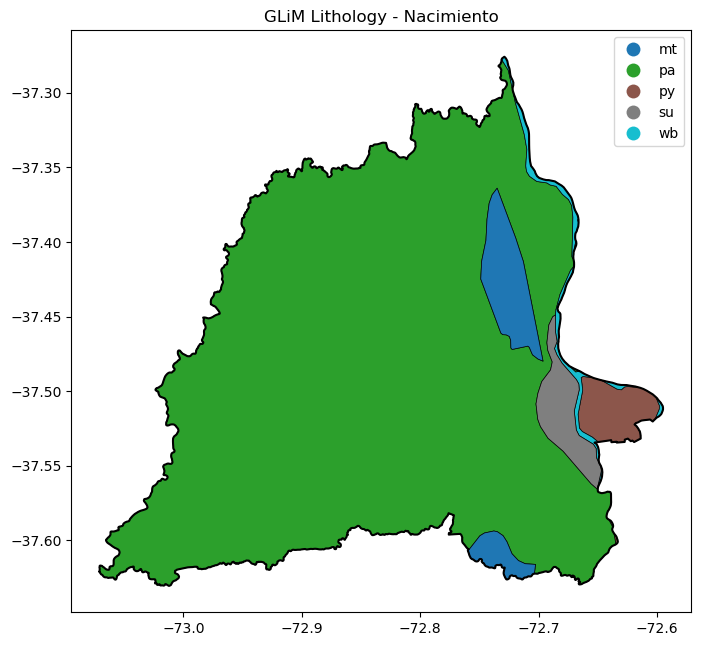

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
glim_nacimiento.plot(column='xx', legend=True, ax=ax, cmap='tab10', edgecolor='black', linewidth=0.5)
nacimiento.boundary.plot(ax=ax, color='black', linewidth=1.5)
ax.set_title('GLiM Lithology - Nacimiento')
plt.show()

## 11. Lithology Reclassification

GLiM lithological classes are reclassified into a 5-level landslide susceptibility scale, based on general rock competence and weathering behavior:

| Susceptibility Class | GLiM code | Lithology | Rationale |
|----------------------|-----------|-----------|-----------|
| 1 (Very Low) | `pa` | Acid plutonic rocks (granitoids) | Competent, well-consolidated rock with high shear strength |
| 2 (Low) | `mt` | Metamorphic rocks | Generally competent, though foliation/schistosity planes can locally reduce stability |
| 3 (Moderate) | *(none present)* | — | *(reserved for intermediate volcanic/sedimentary rocks, not present in this study area)* |
| 4 (High) | `py` | Pyroclastic rocks | Weakly consolidated volcanic ash/tephra deposits, highly susceptible to weathering and saturation |
| 5 (Very High) | `su` | Unconsolidated sediments | Loose alluvial material, minimal cohesion, highest susceptibility |

**Note:** Water bodies (`wb`) are masked out, as landslide susceptibility does not apply to water surfaces.

**Note on weights (to confirm in Session 4):** this ranking follows general geomechanical principles (rock consolidation and cohesion), consistent with common practice in post-fire landslide susceptibility literature. It will be cross-checked against specific papers gathered in Session 4.

In [13]:
# Map lithology codes to susceptibility classes
litho_susceptibility = {
    'pa': 1,
    'mt': 2,
    'py': 4,
    'su': 5,
    'wb': 0  # water - will be masked
}

glim_nacimiento['susceptibility'] = glim_nacimiento['xx'].map(litho_susceptibility)

print(glim_nacimiento[['xx', 'susceptibility']].drop_duplicates())

       xx  susceptibility
55908  py               4
55862  pa               1
55806  wb               0
55926  mt               2
55902  su               5


## 12. Rasterize and Export Geology Layer

Converting the vector lithology susceptibility layer to raster format (matching the resolution and extent of the other conditioning variables), then exporting as a static GeoTIFF.

In [14]:
import rasterio
from rasterio import features
from rasterio.transform import from_bounds
import numpy as np

# Mask out water bodies before rasterizing
glim_for_raster = glim_nacimiento[glim_nacimiento['susceptibility'] > 0]

# Define raster resolution and extent (matching SRTM/slope: 30m)
bounds = nacimiento.total_bounds  # minx, miny, maxx, maxy
resolution = 30 / 111320  # approx conversion from meters to degrees at this latitude

width = int((bounds[2] - bounds[0]) / resolution)
height = int((bounds[3] - bounds[1]) / resolution)

transform = from_bounds(*bounds, width, height)

# Rasterize
shapes = [(geom, value) for geom, value in zip(glim_for_raster.geometry, glim_for_raster['susceptibility'])]
geology_raster = features.rasterize(
    shapes,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    dtype='uint8'
)

print(f"Geology rasterized: shape {geology_raster.shape}")

# Export as GeoTIFF
output_path = '../data/raw/nacimiento_geology_reclass.tif'
with rasterio.open(
    output_path, 'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype='uint8',
    crs=nacimiento.crs,
    transform=transform
) as dst:
    dst.write(geology_raster, 1)

print(f"Geology raster exported to: {output_path}")

Geology rasterized: shape (1315, 1765)
Geology raster exported to: ../data/raw/nacimiento_geology_reclass.tif


## Conclusions

- Land use/land cover derived from ESA WorldCover (10m), reclassified into 5 susceptibility classes based on vegetative root cohesion and surface characteristics. Exported to `data/raw/nacimiento_landuse_reclass.tif`.
- Geology derived from GLiM (Global Lithological Map v1.1), clipped to the Nacimiento study area, reclassified into 5 susceptibility classes based on general rock competence and consolidation. Exported to `data/raw/nacimiento_geology_reclass.tif`.
- **Known limitation:** GLiM's average scale (~1:3,750,000) is considerably coarser than detailed local geological mapping, which may underrepresent fine-scale lithological heterogeneity within the study area. This trade-off was accepted for global consistency, open accessibility, and compatibility with international landslide susceptibility literature.
- All four conditioning variables (dNBR, slope, geology, land use) are now available as static GeoTIFFs in `data/raw/`, ready for the weighted overlay model.
- **Next step (Session 4):** gather literature on post-fire landslide susceptibility weighting schemes, assign weights to each variable, and combine into a final susceptibility raster.